## CARD: Training Session 3

### Solving DAE systems: Modeling a transient CSTR and a steady state PFR

#### Example 1: Generic Differential-Algebraic Equation (DAE)

Problem:

**O**rdinary **D**ifferential **E**quations (**ODE**):

$ \boxed{ \frac{dx}{dt} = \dot{x} = z + 0.1 } $ 

**A**lgebraic **E**quations (**AE**):

$ \boxed{ x = z + 0.1 } $ 

Solve x and z at $t_1 = 1$ with the initial values $ x(t_0 = 0) = 0 $.

**Implementation**:

Import [casADi](https://web.casadi.org/) to solve the DAE

In [1]:
import casadi as casADi

Define necessary differential and algebraic symbolic variables:

In [2]:
x = casADi.SX.sym("x")  # differential
z = casADi.SX.sym("z")  # algebraic

Define ODE by defining the right-hand side:

In [3]:
ode = z + 0.1

Define AE as root-problem:

In [4]:
ae = z * casADi.cos(z) - x

Next a casADi specific dictionary is created with the following entries. The keys (strings in [""]) can not be changed!

In [5]:
dae = {}
dae["x"] = x
dae["z"] = z
dae["ode"] = ode
dae["alg"] = ae

An integrator object for solving the DAE is then defined:

In [6]:
name = "I"
solver = "idas"  # CasADi employs SUNDIALS solver
t0 = 0  # lower integration limit
t1 = 1  # upper integration limit
I = casADi.integrator(name, solver, dae, t0, t1)

Call integrator function:

In [7]:
x0 = 0  # initial/boundary values for differential variable
z0 = 0  # initial guess for algebraic variables
res_dict = I(x0=x0, z0=z0)

Get results from result dictionary (*res_dict*):

In [8]:
res_x = res_dict["xf"].full()
res_z = res_dict["zf"].full()
print("x:", res_x[0, 0])
print("z:", res_z[0, 0])

x: 0.1723999887345893
z: 0.1750763378169946


#### Example 2: Modeling a transient CSTR

![CSTR](./figures/session_3/example1.svg)

**Species conservation**:

$ \boxed{ \frac{dw_i}{dt} = (w_{i, in} - w_{i,out}) \frac{\dot{M}}{V \rho} + \frac{\dot{r}_i M_{w, i}}{\rho} }$

**With the reaction kinetics**:

$ \boxed{ \dot{r}_i = \nu k c_i} $

**Calculate density by assuming ideal gas**:

$\rho = \frac{p M_w}{RT}$ 

$M_w = \left( \sum_i \frac{w_i}{M_{w,i}} \right)^{-1}$ 

$ \boxed{ p = p_0 \frac{M_{w,t=0}}{M_w} }$ 

**Convert mass fraction to molar concentration**:

$c_i = w_i \frac{M_w}{M_{w,i}} c_f$ 

$c_f = \frac{p}{RT}$ 

**Implementation**:

- [NumPy](https://numpy.org/) for math and matrix operations
- [casADi](https://web.casadi.org/) to solve the DAE
- [Matplotlib](https://matplotlib.org/) with the module [pyplot](https://matplotlib.org/3.5.3/api/_as_gen/matplotlib.pyplot.html) to visualize the results

In [ ]:
import casadi as casADi
import matplotlib.pyplot as plt
import numpy as np


Defining necessary differential and algebraic symbolic variables:

In [10]:
w_i = casADi.SX.sym("w_i", 2)   # differential  # [-]   # 0:A, 1:B
p = casADi.SX.sym("p")          # algebraic     # [Pa]

Defining values of constant parameters:

In [11]:
R = 8.314               # [J/K mol]
Mw_i = np.array([2, 1]) # [kg/mol]      # 0:A, 1:B
V_r = 0.1               # [m^2]
T = 300                 # [K]
k = 0.5                 # [1/s]
nu = np.array([-1, 2])  # [-]
dot_M = 1               # [kg/s]

Using an array as upper bound of the integral to calculate various timesteps:

In [12]:
t_0 = 0         # [s]
t_steps = 1000  # [-]
t_end = 20      # [s]
ti = np.linspace(t_0, t_end, t_steps)

Now setting the initial conditions:

In [13]:
p_0 = 1e5               # [Pa]
wi_0 = np.array([1, 0]) # [-]       # 0:A, 1:B

Then setting the inlet condition

In [14]:
wi_in = np.array([1, 0])    # [-]       # 0:A, 1:B

Defining all other variables ($\rho$, $M_w$, $c_f$, $c_i$) implicitly as function of $𝑝$ and $𝑤_i$:

In [15]:
def f_rho(w_i, p):
    rho = p * f_Mw(w_i) / (R * T)
    return rho


def f_Mw(w_i):
    unity = casADi.DM.ones(len(Mw_i))
    Mw = 1 / (casADi.dot(w_i / casADi.SX((Mw_i)), unity))
    return Mw


def f_cf(p):
    cf = p / (R * T)
    return cf


def f_ci(w_i, p):
    c_i = w_i * f_Mw(w_i) / Mw_i * f_cf(p)
    return c_i

Defining the species balance as ODE system with 2 equations using a for-loop:

In [16]:
ode = casADi.SX.sym("ode", 2)
for i in range(len(Mw_i)):
    ode[i] = ((wi_in[i] - w_i[i]) * dot_M / (f_rho(w_i, p) * V_r) + 
              nu[i] * f_ci(w_i, p)[0] * k * Mw_i[i] * 1 / f_rho(w_i, p))

Defining pressure equation as AE ($p = p_0 \frac{M_{w,t=0}}{M_w}$):

In [17]:
ae = p_0 * f_Mw(wi_0) / f_Mw(w_i) - p

Next a casADi specific dictionary is created with the following entries

In [18]:
dae = {}
dae["x"] = w_i
dae["z"] = p
dae["ode"] = ode
dae["alg"] = ae

Then define and call the integrator to solve the DAE:

In [19]:
I = casADi.integrator("I", "idas", dae, t_0, ti)
res_dic = I(x0=wi_0, z0=p_0)
res_w_i = res_dic["xf"].full()
res_p = res_dic["zf"].full()

Plot the results:

Text(0.5, 0, '$t \\; \\mathregular{/s}$')

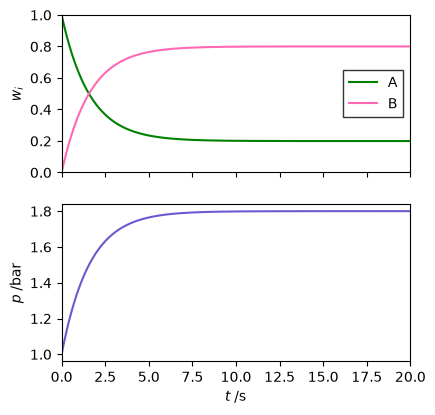

In [20]:
# Create figure and axes of plot
fig, axs = plt.subplots(2, 1, figsize=(4.5, 4.5), sharex=True)

# Plot values
axs[0].plot(ti, res_w_i[0, :], color="green", label="A")
axs[0].plot(ti, res_w_i[1, :], color="hotpink", label="B")

axs[1].plot(ti, res_p.T * 1e-5, color="slateblue")

# Set axis parameters
axs[0].set_ylim(0, 1)
axs[0].set_ylabel("$w_{i}$")
axs[0].legend(fancybox=False, loc="best", edgecolor="black")

axs[1].set_xlim(t_0, t_end)
axs[1].set_ylabel("$p \\; \\mathregular{/bar}$")
axs[1].set_xlabel("$t \\; \\mathregular{/s}$")

#### Example 3: Modeling a steady state **p**lug **f**low **r**eactor (**PFR**)

![PFR](./figures/session_3/example2.svg)

**Species conservation**:

$ \boxed{ \frac{\delta c_1}{\delta t} = -k_1 c_A }$

$ \boxed{ \frac{\delta c_2}{\delta t} = k_1 c_A }$

**With the reaction kinetics**:

$ \boxed{ \dot{r}_i = \nu k c_i} $


**Implementation**:

- [NumPy](https://numpy.org/) for math and matrix operations
- [casADi](https://web.casadi.org/) to solve the DAE
- [Matplotlib](https://matplotlib.org/) with the module [pyplot](https://matplotlib.org/3.5.3/api/_as_gen/matplotlib.pyplot.html) to visualize the results

In [21]:
import casadi as casADi
import matplotlib.pyplot as plt
import numpy as np


Defining necessary differential symbolic variables:

In [22]:
c_i = casADi.SX.sym("c_i", 2)  # [mol/m^3]   # 0:A, 1:B

Defining values of constant parameters:

In [23]:
k = 0.2         # [1/s]
nu = [-1, 1]    # [-]

Now setting the initial conditions:

In [24]:
c_i_0 = np.array([10, 0])  # [mol/m^3]   # 0:A, 1:B

Using an array as upper bound of the integral to calculate various timesteps:

In [25]:
tau_0 = 0       # [s]
tau_steps = 100 # [-]
tau_end = 20    # [s]
tau_i = np.linspace(tau_0, tau_end, tau_steps)

Defining the species balance as ODE system with 2 equations using a for-loop:

In [26]:
ode = casADi.SX.sym("ode", 2)
for i in range(len(nu)):
    ode[i] = nu[i] * k * c_i[0]

Next a casADi specific dictionary is created with the following entries:

In [27]:
dae = {}
dae["x"] = c_i
dae["ode"] = ode

Then define and call the integrator to solve the DAE:

In [28]:
I = casADi.integrator("I", "idas", dae, tau_0, tau_i)
res_dic = I(x0=c_i_0)
res_c_i = res_dic["xf"].full()

Plot the results:

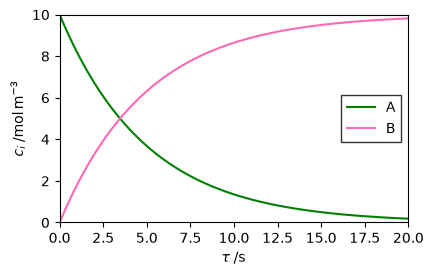

In [29]:
# Create figure and axes of plot
fig, ax = plt.subplots(1, figsize=(4.5, 2.7))

# Plot values
ax.plot(tau_i, res_c_i[0, :], color="green", label="A")
ax.plot(tau_i, res_c_i[1, :], color="hotpink", label="B")

# Set axes parameters
ax.set_ylim(np.min(c_i_0), np.max(c_i_0))
ax.set_xlim(tau_0, tau_end)
ax.set_ylabel("$c_{i} \\; \\mathregular{/mol \\, m^{-3}}$")
ax.set_xlabel("$\\tau \\; \\mathregular{/s}$")
ax.legend(fancybox=False, loc="best", edgecolor="black")